#Regressão em Machine Learning
O exemplo a seguir mostra como construir e comparar, de forma simplificada, modelos de Regressão.

Diferente da Classificação (onde prevemos categorias como "Sim/Não" ou "Aprovado/Reprovado"), na Regressão o nosso objetivo é prever um número contínuo.

Nosso Objetivo: Prever o valor exato da **gorjeta** (tip) em dólares recebida pelos garçons de um restaurante, com base em informações como o valor total da conta, o tamanho da mesa e o dia da semana.

In [1]:
# IMPORTAÇÃO DE BIBLIOTECAS PARA REGRESSÃO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Divisão de dados e Escalonamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importação dos Algoritmos de Regressão
from sklearn.linear_model import LinearRegression         # Regressão Linear (Simples e Múltipla)
from sklearn.tree import DecisionTreeRegressor             # Árvore de Decisão para Regressão
from sklearn.neighbors import KNeighborsRegressor          # k-NN para Regressão
from sklearn.ensemble import RandomForestRegressor         # Floresta Aleatória para Regressão

# Métricas de Avaliação para Regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### Carregamento dos Dados
Vamos carregar a base de dados tips diretamente da internet e visualizar as primeiras linhas para entender a estrutura dos dados.

In [2]:
# IMPORTAÇÃO DOS DADOS

# Carregamento da base de dados 'tips'
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pd.read_csv(url)

# Nosso objetivo de Regressão: Prever o valor exato da gorjeta (coluna 'tip')
print("Primeiras linhas do dataset:")
display(df.head())

Primeiras linhas do dataset:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


###Visualizando os Dados
Antes de treinar qualquer modelo, é fundamental entender visualmente como nossas informações se comportam. Vamos criar gráficos para observar a relação entre o valor da conta e o valor da gorjeta.

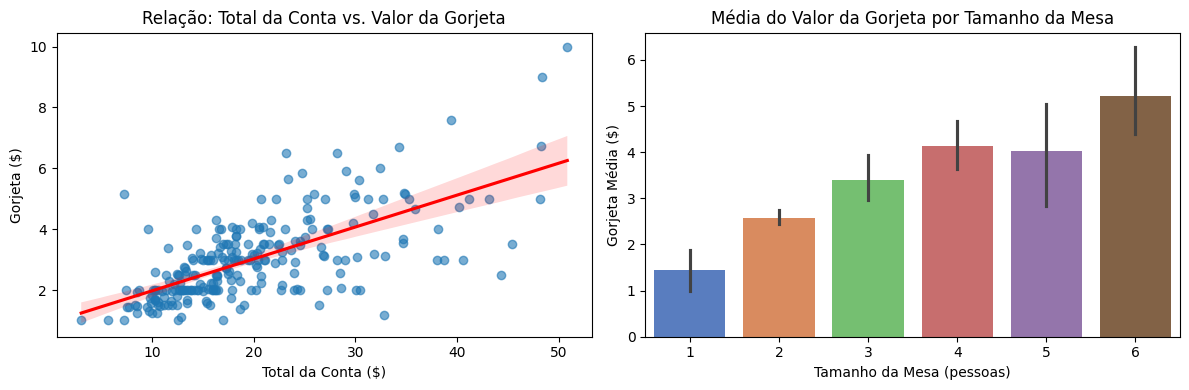

In [3]:
# EXPLORAÇÃO VISUAL

plt.figure(figsize=(12, 4))

# Gráfico 1: Relação entre o valor total da conta (total_bill) e a gorjeta (tip)
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='total_bill', y='tip', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Relação: Total da Conta vs. Valor da Gorjeta")
plt.xlabel("Total da Conta ($)")
plt.ylabel("Gorjeta ($)")

# Gráfico 2: Média da gorjeta por tamanho da mesa
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='size', y='tip', palette='muted')
plt.title("Média do Valor da Gorjeta por Tamanho da Mesa")
plt.xlabel("Tamanho da Mesa (pessoas)")
plt.ylabel("Gorjeta Média ($)")

plt.tight_layout()
plt.show()

###Preparação dos Dados (Pré-processamento)
Para que os modelos matemáticos consigam processar as informações, precisamos fazer algumas etapas de preparação:

**Transformar texto em número**: Converter colunas categóricas (como sexo, dia e horário) em dados numéricos.

**Definir o Alvo (y)**: Nossa variável de saída será o valor da gorjeta (tip).

**Dividir Treino e Teste**: Separar 80% dos dados para ensinar os modelos e 20% para testar a precisão deles.

**Padronizar a Escala**: Deixar as variáveis na mesma ordem de grandeza para não confundir algoritmos como o KNN.

In [4]:
# TRATAMENTO DE VARIÁVEIS CATEGÓRICAS E DIVISÃO DOS DADOS

# Converte variáveis categóricas (sex, smoker, day, time) em colunas numéricas (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# Definição do Alvo (Target) -> Valor da gorjeta (variável contínua)
y = df_encoded['tip']

# 1. Conjunto de dados para Regressão Linear Simples (Apenas 1 variável preditora: 'total_bill')
X_simples = df_encoded[['total_bill']]

# 2. Conjunto de dados para Regressão Múltipla e demais modelos (Todas as variáveis explicativas)
X_multiplo = df_encoded.drop(columns=['tip'])

# Divisão em Treino (80%) e Teste (20%)
X_train_s, X_test_s, y_train, y_test = train_test_split(X_simples, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, _, _            = train_test_split(X_multiplo, y, test_size=0.2, random_state=42)

# Padronização/Escalonamento das variáveis (Essencial para KNN e Regressão Linear)
scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

###Treinamento Inicial dos Modelos
Vamos instanciar e treinar os 5 modelos de regressão com nossos dados de treino.

In [5]:
# Dicionário com os modelos
modelos = {
    "Regressão Linear Simples": (LinearRegression(), X_train_s_scaled, X_test_s_scaled),
    "Regressão Linear Múltipla": (LinearRegression(), X_train_m_scaled, X_test_m_scaled),
    "Árvore de Decisão": (DecisionTreeRegressor(max_depth=4, random_state=42), X_train_m, X_test_m),
    "KNN Regressor": (KNeighborsRegressor(n_neighbors=5), X_train_m_scaled, X_test_m_scaled),
    "Floresta Aleatória": (RandomForestRegressor(n_estimators=100, random_state=42), X_train_m, X_test_m)
}

# Treinando todos os modelos
for nome, (modelo, X_tr, _) in modelos.items():
    modelo.fit(X_tr, y_train)

print("Todos os modelos foram treinados com sucesso!")

Todos os modelos foram treinados com sucesso!


###Parte 1: Inferência Individual (Previsão para um Novo Cliente)
Agora que os modelos estão treinados, vamos simular a chegada de um novo cliente ao restaurante e estimar o valor da gorjeta que ele deixará.

Dados do Novo Cliente:

1. Valor total da conta: $45.50

2. Tamanho da mesa: 4 pessoas

3. Sexo do pagador: Feminino

4. Fumante na mesa: Não

5. Dia: Domingo

6. Horário: Jantar

In [6]:
# Criação do perfil do novo cliente em um DataFrame
novo_cliente = pd.DataFrame({
    'total_bill': [45.50],
    'sex': ['Female'],
    'smoker': ['No'],
    'day': ['Sun'],
    'time': ['Dinner'],
    'size': [4]
})

# Ajustando a codificação para alinhar com as colunas do modelo
novo_cliente_encoded = pd.get_dummies(novo_cliente)
novo_cliente_encoded = novo_cliente_encoded.reindex(columns=X_multiplo.columns, fill_value=0)

# Previsão utilizando a Floresta Aleatória
modelo_rf = modelos["Floresta Aleatória"][0]
gorjeta_estimada = modelo_rf.predict(novo_cliente_encoded)[0]

print("=== SIMULAÇÃO DE INFERÊNCIA INDIVIDUAL ===")
print(f"Valor da conta: $45.50 | Pessoas: 4")
print(f"-> Gorjeta estimada pelo modelo: $ {gorjeta_estimada:.2f}")

=== SIMULAÇÃO DE INFERÊNCIA INDIVIDUAL ===
Valor da conta: $45.50 | Pessoas: 4
-> Gorjeta estimada pelo modelo: $ 5.88


###Parte 2: Análise Final e Comparação dos Modelos
Para entender qual modelo teve o melhor desempenho geral, avaliamos todos eles no conjunto de teste (dados que eles nunca viram durante o treinamento).

Métricas Utilizadas:
Erro Médio ($): A margem de erro aproximada em dólares para mais ou para menos nas previsões. Quanto menor, melhor!

##Entendendo as Métricas de Avaliação na Prática

Como sabemos se nosso modelo está acertando ou errando? Utilizamos duas métricas simples:

###Erro Médio ($) — (RMSE)Representa a diferença média em dólares entre o valor real da gorjeta e o valor prevendo pelo modelo.

Exemplo de Cálculo:Imagine que testamos o modelo em apenas 3 mesas:
1. Mesa 01 -> Gorjeta Real = 5  || GorjetaPrevista = 4
2. Mesa 02 -> Gorjeta Real = 3  || GorjetaPrevista = 5
3. Mesa 03 -> Gorjeta Real = 9  || GorjetaPrevista = 7

**Média dos Erros ao Quadrado**: (1.00 + 4.00 + 4.00) / 3 = 3

Erro Médio (Raiz Quadrada): sqrt(3) ~= 1.7320
**Interpretação**: Em média, o modelo está errando o valor da gorjeta por 1.7320 (para mais ou para menos). Quanto menor esse valor, melhor o modelo.


In [7]:
resultados = []

# Avaliação no conjunto de teste
for nome, (modelo, _, X_te) in modelos.items():
    y_pred = modelo.predict(X_te)

    # Cálculo das métricas simplificadas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultados.append({
        "Modelo": nome,
        "Erro Médio ($)": f"$ {rmse:.2f}",
    })

# Tabela Comparativa de Desempenho
df_resultados = pd.DataFrame(resultados)
print("=== TABELA COMPARATIVA DOS MODELOS ===")
display(df_resultados)

=== TABELA COMPARATIVA DOS MODELOS ===


,Modelo,Erro Médio ($)
0,Regressão Linear Simples,$ 0.75
1,Regressão Linear Múltipla,$ 0.84
2,Árvore de Decisão,$ 1.00
3,KNN Regressor,$ 0.95
4,Floresta Aleatória,$ 0.96


Para visualizar o desempenho real de cada ponto de teste:

1. Cada ponto azul/roxo/amarelo representa uma mesa real.

**Gradiente de Cor**: As cores dos pontos indicam o tamanho do erro (diferença em dólares entre a gorjeta real e a prevista).

1. Cores escuras (Roxo/Azul): Erros pequenos (alta precisão).

2. Cores vivas (Amarelo/Laranja): Erros maiores naquela mesa específica.

**Linha Vermelha:** Linha de referência da predição perfeita. Quanto mais próximo da linha, menor o erro do ponto.

 MODELO: 1. REGRESSÃO LINEAR SIMPLES
 Erro Médio (RMSE) : $ 0.75
-----------------------------------------------------------------


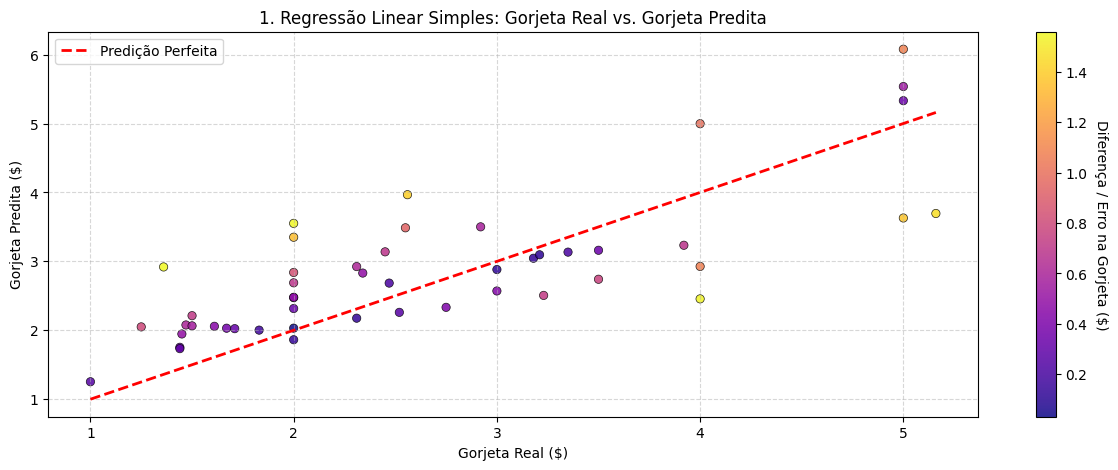



 MODELO: 2. REGRESSÃO LINEAR MÚLTIPLA
 Erro Médio (RMSE) : $ 0.84
-----------------------------------------------------------------


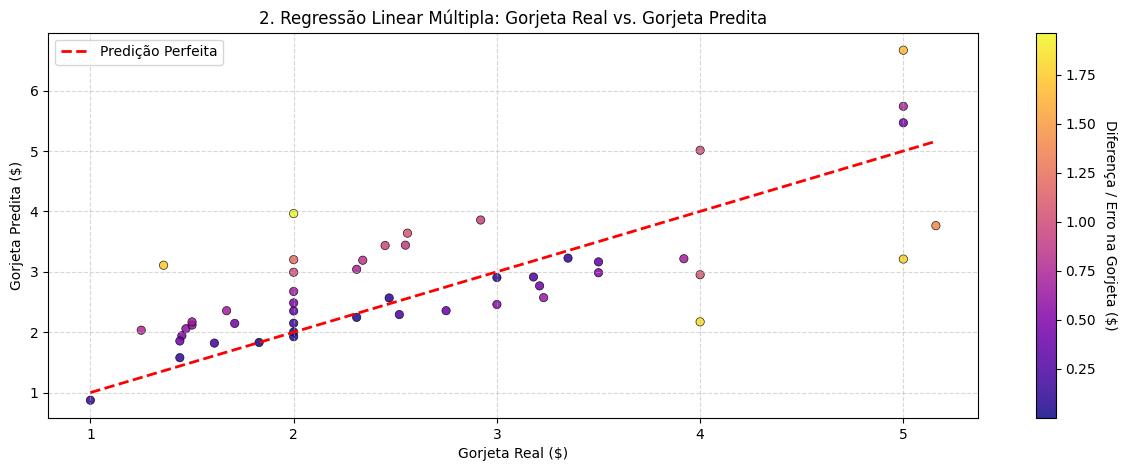



 MODELO: 3. ÁRVORE DE DECISÃO
 Erro Médio (RMSE) : $ 1.00
-----------------------------------------------------------------


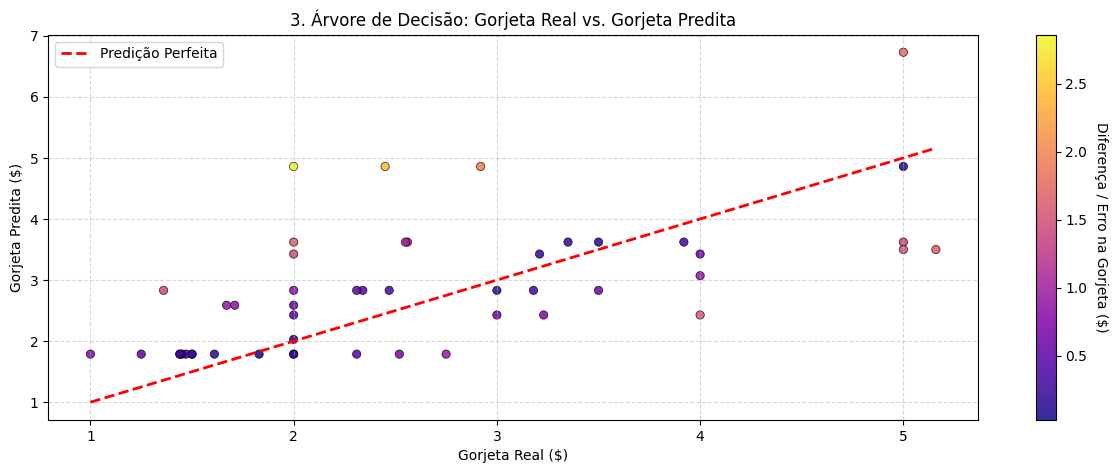



 MODELO: 4. KNN REGRESSOR
 Erro Médio (RMSE) : $ 0.95
-----------------------------------------------------------------


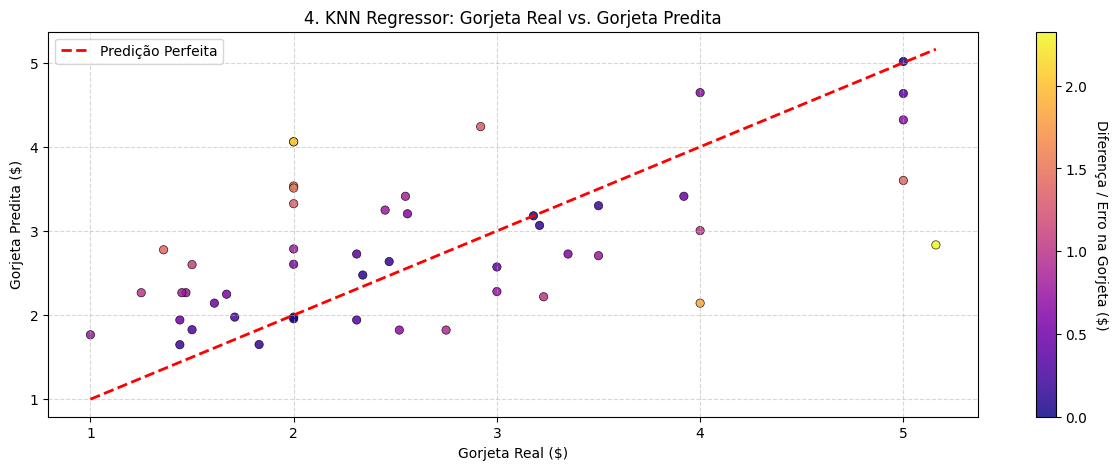



 MODELO: 5. FLORESTA ALEATÓRIA
 Erro Médio (RMSE) : $ 0.96
-----------------------------------------------------------------


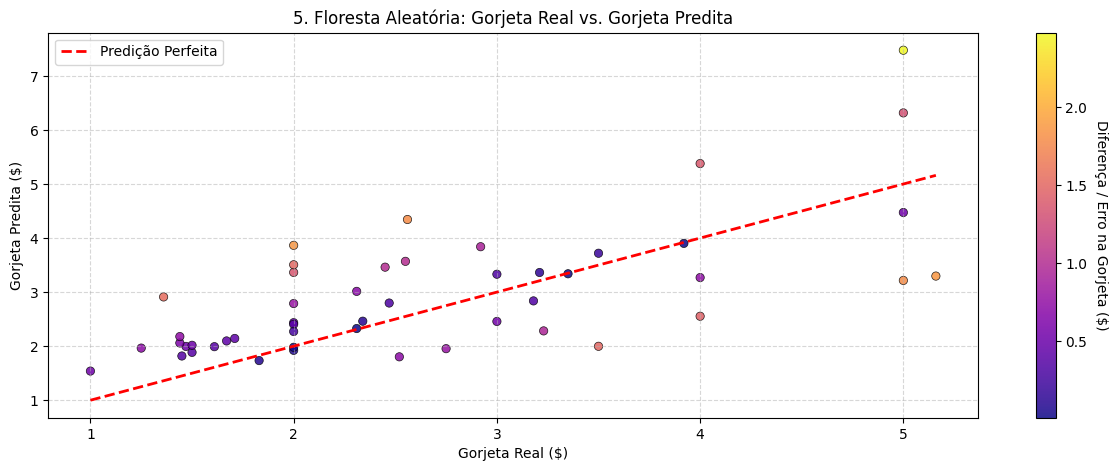

In [8]:
# Dicionário configurado com os 5 modelos
modelos = {
    "1. Regressão Linear Simples": (LinearRegression(), X_train_s_scaled, X_test_s_scaled),
    "2. Regressão Linear Múltipla": (LinearRegression(), X_train_m_scaled, X_test_m_scaled),
    "3. Árvore de Decisão": (DecisionTreeRegressor(max_depth=4, random_state=42), X_train_m, X_test_m),
    "4. KNN Regressor": (KNeighborsRegressor(n_neighbors=5), X_train_m_scaled, X_test_m_scaled),
    "5. Floresta Aleatória": (RandomForestRegressor(n_estimators=100, random_state=42), X_train_m, X_test_m)
}

# Lista para guardar os resultados para a tabela final
historico_resultados = []

# Loop de avaliação individual por modelo
for nome, (modelo, X_tr, X_te) in modelos.items():
    # Treinamento
    modelo.fit(X_tr, y_train)

    # Predição
    y_pred = modelo.predict(X_te)

    # Cálculo das Métricas Gerais
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Cálculo da diferença/erro individual de cada ponto de teste
    diferencas_individuais = np.abs(y_test - y_pred)

    # Guarda os resultados globais
    historico_resultados.append({
        "Modelo": nome,
        "Erro Médio ($)": f"$ {rmse:.2f}",
    })

    # Exibição dos resultados numéricos do modelo
    print("=" * 65)
    print(f" MODELO: {nome.upper()}")
    print("=" * 65)
    print(f" Erro Médio (RMSE) : $ {rmse:.2f}")
    print("-" * 65)

    # Gráfico individual destacando a diferença/erro de cada ponto por cor
    plt.figure(figsize=(15, 5))
    scatter = plt.scatter(
        y_test,
        y_pred,
        c=diferencas_individuais,
        cmap='plasma',
        alpha=0.85,
        edgecolors='black',
        linewidth=0.5
    )

    # Linha de referência da predição perfeita
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predição Perfeita')

    # Barra lateral de cores mostrando a escala do erro
    cbar = plt.colorbar(scatter)
    cbar.set_label('Diferença / Erro na Gorjeta ($)', rotation=270, labelpad=15)

    plt.title(f"{nome}: Gorjeta Real vs. Gorjeta Predita")
    plt.xlabel("Gorjeta Real ($)")
    plt.ylabel("Gorjeta Predita ($)")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    print("\n")

 MODELO: 1. REGRESSÃO LINEAR SIMPLES
 Erro Médio (RMSE) : $ 0.75
-----------------------------------------------------------------


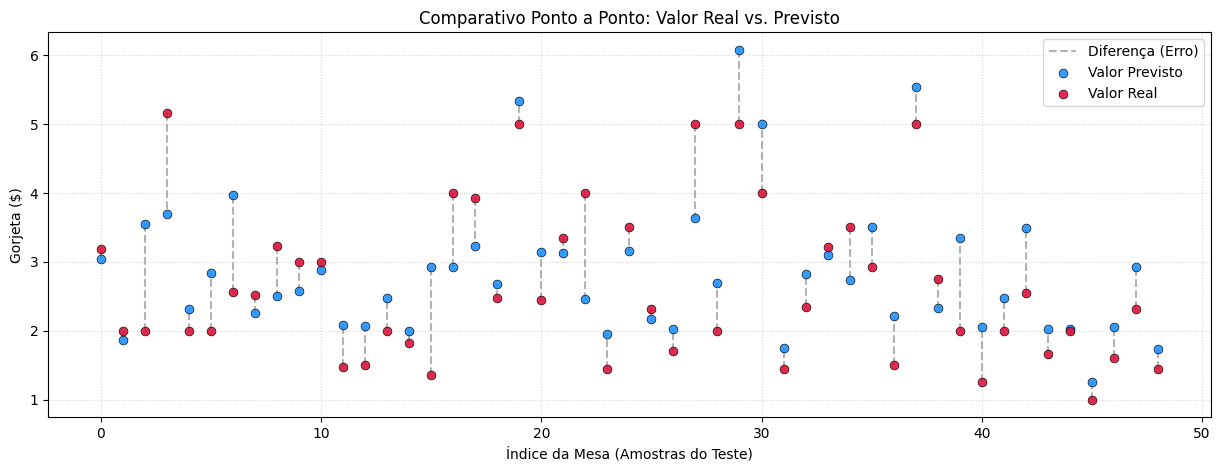



 MODELO: 2. REGRESSÃO LINEAR MÚLTIPLA
 Erro Médio (RMSE) : $ 0.84
-----------------------------------------------------------------


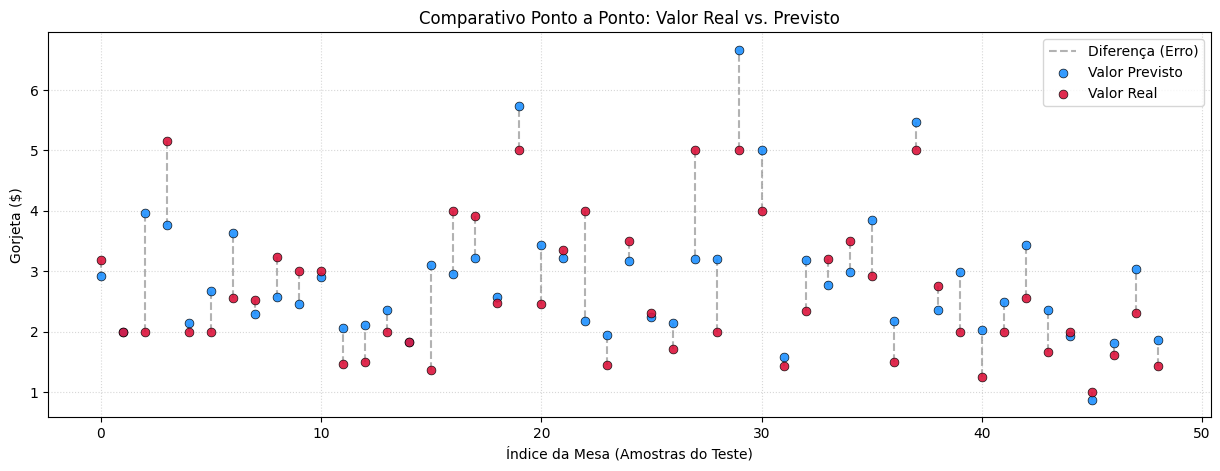



 MODELO: 3. ÁRVORE DE DECISÃO
 Erro Médio (RMSE) : $ 1.00
-----------------------------------------------------------------


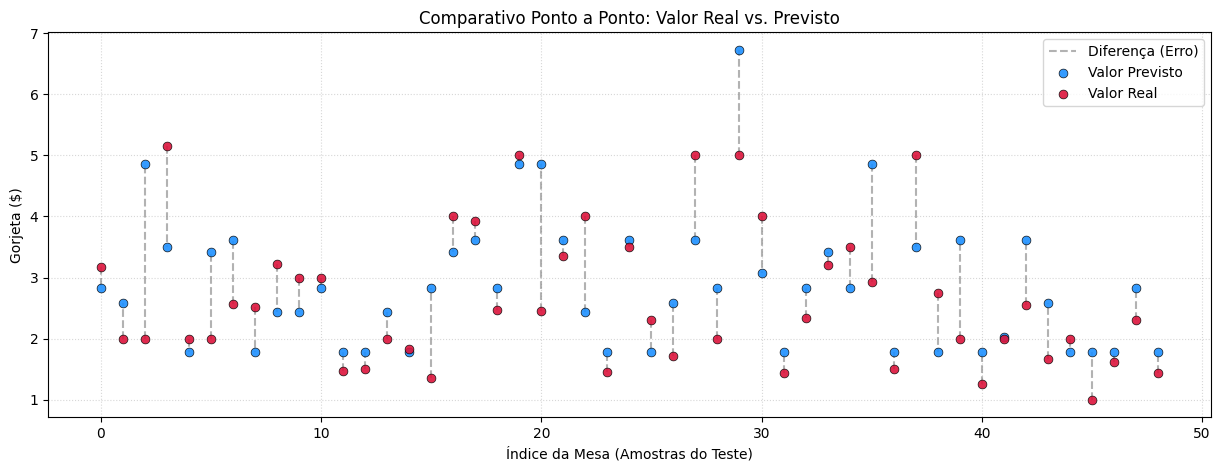



 MODELO: 4. KNN REGRESSOR
 Erro Médio (RMSE) : $ 0.95
-----------------------------------------------------------------


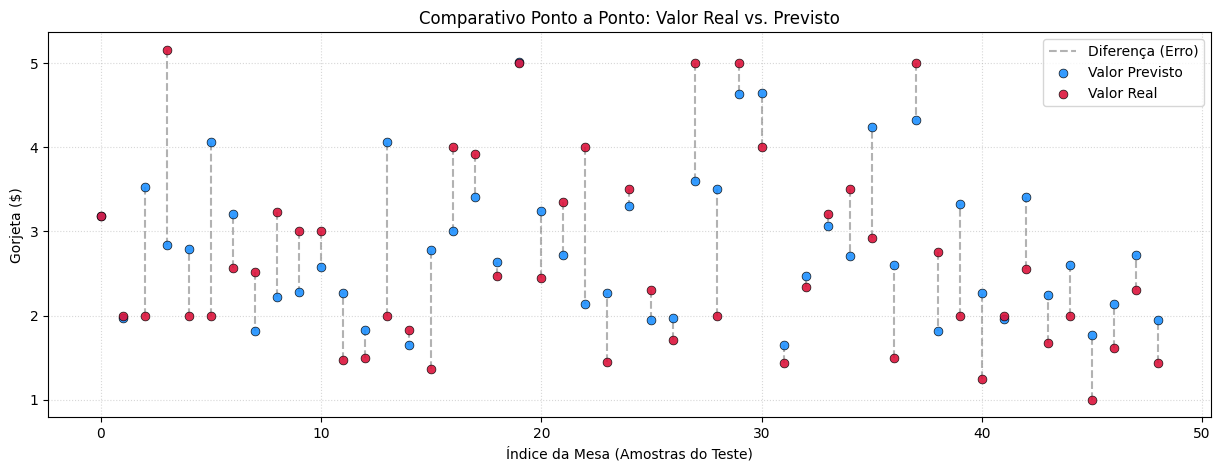



 MODELO: 5. FLORESTA ALEATÓRIA
 Erro Médio (RMSE) : $ 0.96
-----------------------------------------------------------------


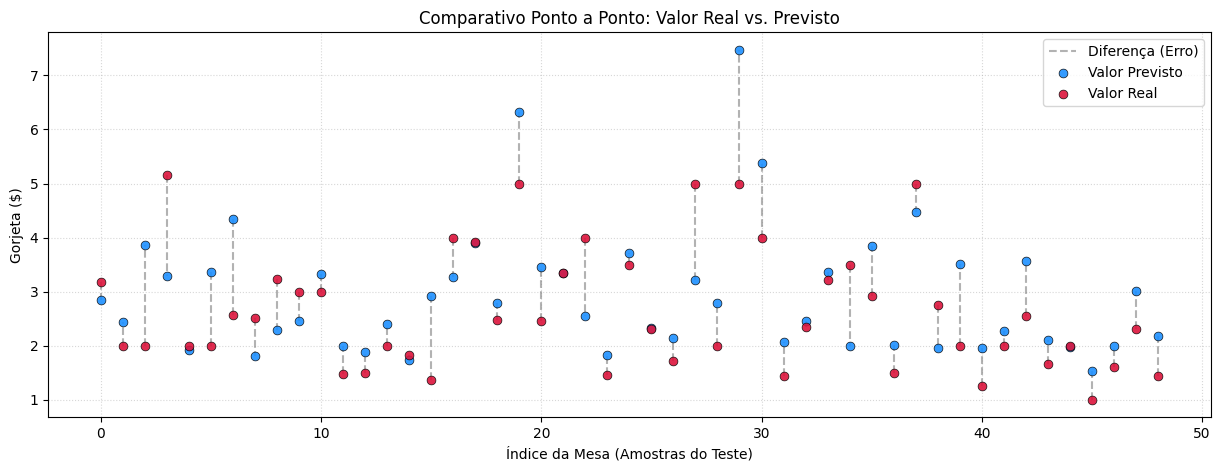

In [9]:
# Dicionário configurado com os 5 modelos
modelos = {
    "1. Regressão Linear Simples": (LinearRegression(), X_train_s_scaled, X_test_s_scaled),
    "2. Regressão Linear Múltipla": (LinearRegression(), X_train_m_scaled, X_test_m_scaled),
    "3. Árvore de Decisão": (DecisionTreeRegressor(max_depth=4, random_state=42), X_train_m, X_test_m),
    "4. KNN Regressor": (KNeighborsRegressor(n_neighbors=5), X_train_m_scaled, X_test_m_scaled),
    "5. Floresta Aleatória": (RandomForestRegressor(n_estimators=100, random_state=42), X_train_m, X_test_m)
}

# Lista para guardar os resultados para a tabela final
historico_resultados = []

# Loop de avaliação individual por modelo
for nome, (modelo, X_tr, X_te) in modelos.items():
    # Treinamento
    modelo.fit(X_tr, y_train)

    # Predição
    y_pred = modelo.predict(X_te)

    # Cálculo das Métricas Gerais
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Cálculo da diferença/erro individual de cada ponto de teste
    diferencas_individuais = np.abs(y_test - y_pred)

    # Guarda os resultados globais
    historico_resultados.append({
        "Modelo": nome,
        "Erro Médio ($)": f"$ {rmse:.2f}",
    })

    # Exibição dos resultados numéricos do modelo
    print("=" * 65)
    print(f" MODELO: {nome.upper()}")
    print("=" * 65)
    print(f" Erro Médio (RMSE) : $ {rmse:.2f}")
    print("-" * 65)

    plt.figure(figsize=(15, 5))

    # Criando a lista de índices x (0, 1, 2, ...)
    x_indices = range(len(y_pred))

    # 1. Linha vertical conectando o valor Real ao Previsto para cada índice
    plt.vlines(
        x=x_indices,
        ymin=y_test,
        ymax=y_pred,
        color='gray',
        alpha=0.6,
        linestyle='--',
        label='Diferença (Erro)'
    )

    # 2. Pontos com os Valores PREVISTOS (exemplo: azul)
    plt.scatter(
        x_indices,
        y_pred,
        color='dodgerblue',
        s=40,
        alpha=0.9,
        edgecolors='black',
        linewidth=0.5,
        label='Valor Previsto',
        zorder=3
    )

    # 3. Pontos com os Valores REAIS (exemplo: vermelho)
    plt.scatter(
        x_indices,
        y_test,
        color='crimson',
        s=40,
        alpha=0.9,
        edgecolors='black',
        linewidth=0.5,
        label='Valor Real',
        zorder=3
    )

    plt.title("Comparativo Ponto a Ponto: Valor Real vs. Previsto")
    plt.xlabel("Índice da Mesa (Amostras do Teste)")
    plt.ylabel("Gorjeta ($)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()
    print("\n")